# EF7

## Presentación de los datos

El dataset tiene datos de estudiantes, una fila por cada estudiante, los elementos mas de cuidado son las escalas de las notas, ya que las relacionadas a ingreso tienen una escala de 0 a 200 y el promedio una escala de 0 a 20. Los datos de contexto economico son porcentuales.

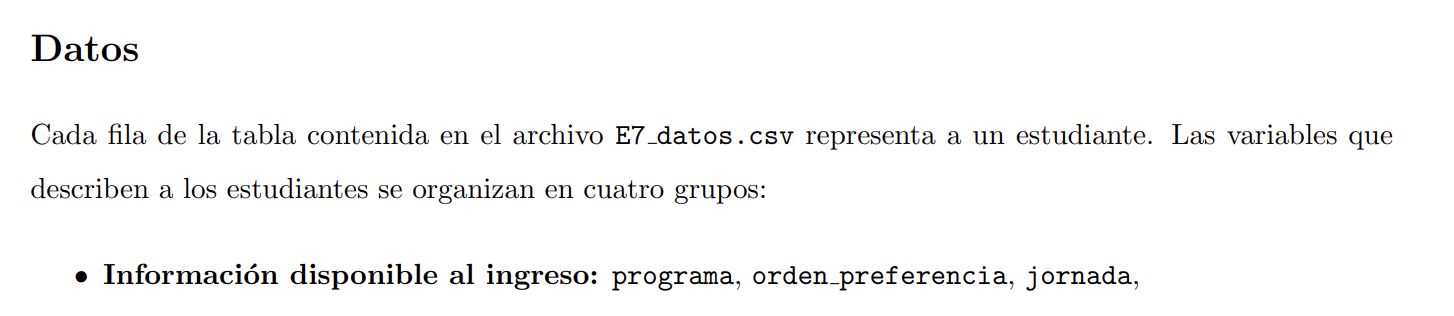

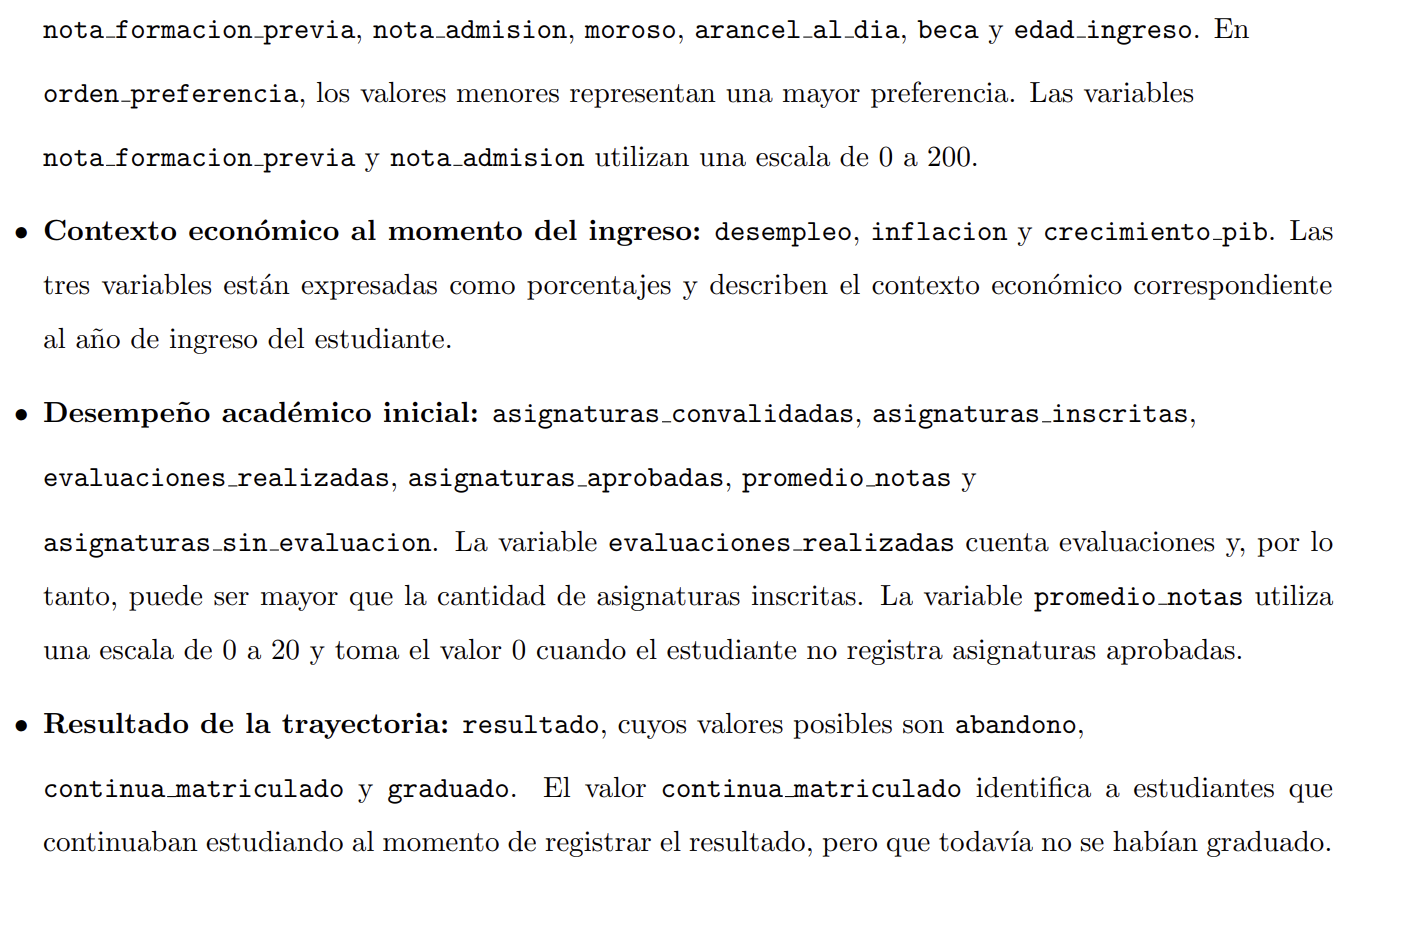

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datos = pd.read_csv('E7_datos.csv')
datos.head()

,programa,orden_preferencia,jornada,nota_formacion_previa,nota_admision,moroso,arancel_al_dia,beca,edad_ingreso,desempleo,inflacion,crecimiento_pib,asignaturas_convalidadas,asignaturas_inscritas,evaluaciones_realizadas,asignaturas_aprobadas,promedio_notas,asignaturas_sin_evaluacion,resultado
0,Diseño de animación y multimedia,5,diurna,122.0,127.3,0,1,0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,abandono
1,Turismo,1,diurna,160.0,142.5,0,0,0,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,graduado
2,Diseño de comunicación,5,diurna,122.0,124.8,0,0,0,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,abandono
3,Periodismo y comunicación,2,diurna,122.0,119.6,0,1,0,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,graduado
4,Servicio social,1,vespertina,100.0,141.5,0,1,0,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,graduado


## Revisión de calidad de los datos

Se revisan valores nulos, textos en blanco, filas duplicadas y valores fuera de las escalas indicadas en el enunciado.

In [74]:
datos.isnull().sum()

,0
programa,0
orden_preferencia,0
jornada,0
nota_formacion_previa,0
nota_admision,0
moroso,0
arancel_al_dia,0
beca,0
edad_ingreso,0
desempleo,0


In [75]:
columnas_texto = ['programa', 'jornada', 'resultado']

for columna in columnas_texto:
    texto = datos[columna].str.strip()
    blancos = (texto == '').sum()
    print(f'{columna}: {blancos} valores en blanco')

programa: 0 valores en blanco
jornada: 0 valores en blanco
resultado: 0 valores en blanco


In [76]:
duplicados = datos.duplicated(keep=False)

print(f'Filas duplicadas: {duplicados.sum()}')
datos[duplicados]

Filas duplicadas: 2


,programa,orden_preferencia,jornada,nota_formacion_previa,nota_admision,moroso,arancel_al_dia,beca,edad_ingreso,desempleo,inflacion,crecimiento_pib,asignaturas_convalidadas,asignaturas_inscritas,evaluaciones_realizadas,asignaturas_aprobadas,promedio_notas,asignaturas_sin_evaluacion,resultado
1058,Gestión de publicidad y marketing,1,diurna,133.1,100.0,1,0,0,25,9.4,-0.8,-3.12,0,5,5,5,11.2,0,abandono
2089,Gestión de publicidad y marketing,1,diurna,133.1,100.0,1,0,0,25,9.4,-0.8,-3.12,0,5,5,5,11.2,0,abandono


Hay dos filas con los mismos valores. El enunciado indica que cada fila es un estudiante distinto, y con variables de pocos valores posibles es esperable que dos estudiantes coincidan. Por eso ambas filas se conservan.

In [77]:
fuera_escala_ingreso = (datos['nota_admision'] > 200) | (datos['nota_formacion_previa'] > 200)
fuera_escala_notas = datos['promedio_notas'] > 20
aprobadas_mayor_inscritas = datos['asignaturas_aprobadas'] > datos['asignaturas_inscritas']
promedio_sin_aprobadas = (datos['asignaturas_aprobadas'] == 0) & (datos['promedio_notas'] > 0)

print(f'Notas de ingreso sobre 200: {fuera_escala_ingreso.sum()}')
print(f'Promedio de notas sobre 20: {fuera_escala_notas.sum()}')
print(f'Aprobadas mayores que inscritas: {aprobadas_mayor_inscritas.sum()}')
print(f'Promedio mayor a 0 sin aprobadas: {promedio_sin_aprobadas.sum()}')

Notas de ingreso sobre 200: 0
Promedio de notas sobre 20: 0
Aprobadas mayores que inscritas: 0
Promedio mayor a 0 sin aprobadas: 0


No hay nulos, blancos ni valores fuera de escala, y las variables de desempeño son coherentes entre sí.

### Revisión de valores cero

Un cero no siempre es un dato faltante. Se revisa cada variable con ceros para decidir si tiene un significado real en el problema.

In [78]:
columnas_numericas = datos.select_dtypes(include='number').columns
ceros = (datos[columnas_numericas] == 0).sum()

ceros[ceros > 0]

,0
orden_preferencia,1
moroso,3921
arancel_al_dia,528
beca,3325
asignaturas_convalidadas,3847
asignaturas_inscritas,180
evaluaciones_realizadas,349
asignaturas_aprobadas,718
promedio_notas,718
asignaturas_sin_evaluacion,4130


En moroso, arancel_al_dia y beca el cero significa no. En asignaturas_convalidadas y asignaturas_sin_evaluacion el cero es el caso más común, porque la mayoría no convalida y evalúa todas sus asignaturas. Estos ceros se conservan.

In [79]:
sin_inscritas = datos['asignaturas_inscritas'] == 0
print(f'Estudiantes sin asignaturas inscritas: {sin_inscritas.sum()}')

columnas_actividad = ['asignaturas_convalidadas', 'evaluaciones_realizadas',
                      'asignaturas_aprobadas', 'asignaturas_sin_evaluacion']
actividad_sin_inscritas = datos.loc[sin_inscritas, columnas_actividad]
print(actividad_sin_inscritas.sum())

datos.loc[sin_inscritas, 'resultado'].value_counts(normalize=True)

Estudiantes sin asignaturas inscritas: 180
asignaturas_convalidadas      0
evaluaciones_realizadas       0
asignaturas_aprobadas         0
asignaturas_sin_evaluacion    0
dtype: int64


,proportion
resultado,
abandono,0.427778
graduado,0.416667
continua_matriculado,0.155556


Estos estudiantes no registran ninguna actividad académica en el periodo inicial, y el 42% igual termina graduado. Puede tratarse de estudiantes que comenzaron sus asignaturas más tarde. El cero describe una situación real, así que se conservan. Hay que tenerlo en cuenta en la Misión 1, porque las tasas que dividen por asignaturas inscritas quedan sin definir.

In [80]:
inscritas_sin_evaluaciones = (datos['asignaturas_inscritas'] > 0) & (datos['evaluaciones_realizadas'] == 0)
print(f'Inscritos sin evaluaciones realizadas: {inscritas_sin_evaluaciones.sum()}')

datos.loc[inscritas_sin_evaluaciones, 'resultado'].value_counts(normalize=True)

Inscritos sin evaluaciones realizadas: 169


,proportion
resultado,
abandono,1.0


Todos estos estudiantes abandonan. Inscribir asignaturas y no rendir evaluaciones es una señal fuerte de abandono, así que estos ceros son información útil y se conservan.

In [81]:
sin_aprobadas = datos['asignaturas_aprobadas'] == 0
promedio_cero = datos['promedio_notas'] == 0

print(f'Estudiantes sin asignaturas aprobadas: {sin_aprobadas.sum()}')
print(f'Estudiantes con promedio 0: {promedio_cero.sum()}')
print(f'Ambos grupos coinciden: {(sin_aprobadas == promedio_cero).all()}')

datos.loc[promedio_cero, 'resultado'].value_counts(normalize=True)

Estudiantes sin asignaturas aprobadas: 718
Estudiantes con promedio 0: 718
Ambos grupos coinciden: True


,proportion
resultado,
abandono,0.793872
graduado,0.107242
continua_matriculado,0.098886


El promedio 0 coincide exactamente con no tener asignaturas aprobadas, como indica el enunciado. Este valor funciona como un indicador y no como una nota real de 0. Se conserva porque separa un grupo donde el 79% abandona.

### Valores negativos y extremos

In [82]:
valores_inflacion = datos['inflacion'].unique()
valores_pib = datos['crecimiento_pib'].unique()

print('Valores de inflación:', np.sort(valores_inflacion))
print('Valores de crecimiento del PIB:', np.sort(valores_pib))

Valores de inflación: [-0.8 -0.3  0.3  0.5  0.6  1.4  2.6  2.8  3.7]
Valores de crecimiento del PIB: [-4.06 -3.12 -1.7  -0.92  0.32  0.79  1.74  1.79  2.02  3.51]


Los negativos en inflación y crecimiento del PIB corresponden a años con deflación o recesión. Son valores reales del contexto económico y se conservan.

In [83]:
print(datos['orden_preferencia'].value_counts().sort_index())

mayores_50 = datos['edad_ingreso'] > 50
print(f'Estudiantes que ingresan con más de 50 años: {mayores_50.sum()}')
print(f'Edad máxima: {datos["edad_ingreso"].max()}')

orden_preferencia
0       1
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
Name: count, dtype: int64
Estudiantes que ingresan con más de 50 años: 43
Edad máxima: 70


Hay un estudiante con orden de preferencia 0. Según el enunciado, un valor menor indica más preferencia, así que 0 sigue siendo interpretable. Como es un solo caso, se conserva.

Las edades altas corresponden a estudiantes adultos, que son un caso real en educación superior, y también se conservan.

En resumen, no se elimina ningún registro ni valor. Los ceros, negativos y extremos tienen una interpretación dentro del problema. El único tratamiento necesario son las tasas de los estudiantes sin asignaturas inscritas.

## Misión 1: Preparación de las trayectorias

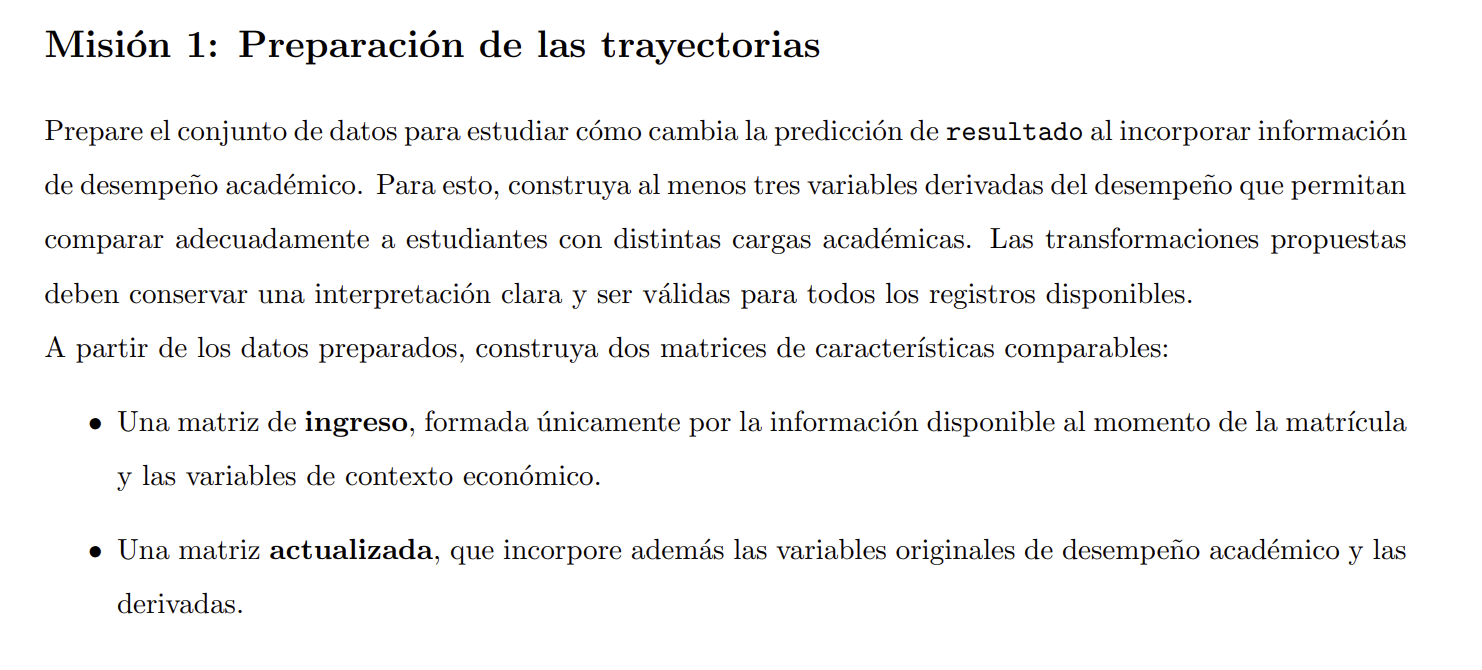

Para iniciar el desarrollo definimos las tres variables asociadas a desempeño:



1.   Tasa de aprobación: Proporción de ramos aprobados entre ramos totales inscritos.
2.   Evaluaciones por asignatura: Valor medio de evaluaciones realizadas por la totalidad de ramos inscritos.
3. Tasa sin evaluación: Proporción de ramos sin evaluación contra los totales.



In [84]:
datos['tasa_aprobacion'] = datos['asignaturas_aprobadas'] / datos['asignaturas_inscritas']
datos['evaluaciones_por_asignatura'] = datos['evaluaciones_realizadas'] / datos['asignaturas_inscritas']
datos['tasa_sin_evaluacion'] = datos['asignaturas_sin_evaluacion'] / datos['asignaturas_inscritas']

derivadas = ['tasa_aprobacion', 'evaluaciones_por_asignatura', 'tasa_sin_evaluacion']

datos[derivadas].isnull().sum()

,0
tasa_aprobacion,180
evaluaciones_por_asignatura,180
tasa_sin_evaluacion,180


En particular, considerando a los estudiantes sin asignaturas inscritas, las tasas anteriores les darian 0/0, por lo que se deben resolver con 0.

In [85]:
datos[derivadas] = datos[derivadas].fillna(0)
datos[derivadas].describe()

,tasa_aprobacion,evaluaciones_por_asignatura,tasa_sin_evaluacion
count,4424.000000,4424.00000,4424.000000
mean,0.697885,1.29034,0.021742
std,0.365247,0.56732,0.103236
min,0.000000,0.00000,0.000000
25%,0.500000,1.00000,0.000000
50%,0.833333,1.20000,0.000000
75%,1.000000,1.60000,0.000000
max,1.000000,3.50000,1.000000


Comenzamos con la obtención de las matrices de características. Antes de eso sin embargo se deben terminar por serializar los valores del dataset que serán usados para la construcción de las matrices, que son los campos de jornada, resultado y programa.

In [86]:
from sklearn.preprocessing import LabelEncoder

codificador = LabelEncoder()
datos['resultado'] = codificador.fit_transform(datos['resultado'])
print(codificador.classes_)

codificador_jornada = LabelEncoder()
datos['jornada'] = codificador_jornada.fit_transform(datos['jornada'])

datos = pd.get_dummies(datos, columns=['programa'], dtype=int)
datos.head()

['abandono' 'continua_matriculado' 'graduado']


,orden_preferencia,jornada,nota_formacion_previa,nota_admision,moroso,arancel_al_dia,beca,edad_ingreso,desempleo,inflacion,...,programa_Enfermería,programa_Enfermería veterinaria,programa_Equinocultura,programa_Gestión de publicidad y marketing,programa_Higiene oral,programa_Ingeniería informática,programa_Periodismo y comunicación,programa_Servicio social,programa_Tecnologías de producción de biocombustibles,programa_Turismo
0,5,0,122.0,127.3,0,1,0,20,10.8,1.4,...,0,0,0,0,0,0,0,0,0,0
1,1,0,160.0,142.5,0,0,0,19,13.9,-0.3,...,0,0,0,0,0,0,0,0,0,1
2,5,0,122.0,124.8,0,0,0,19,10.8,1.4,...,0,0,0,0,0,0,0,0,0,0
3,2,0,122.0,119.6,0,1,0,20,9.4,-0.8,...,0,0,0,0,0,0,1,0,0,0
4,1,1,100.0,141.5,0,1,0,45,13.9,-0.3,...,0,0,0,0,0,0,0,1,0,0


Luego volviendo al enunciado, nos piden segmentar las matrices por las variables asociadas al ingreso del estudiante y a su desempeño actualizado, es decir considerando sus variables de ingreso, como va su desempeño. Por programna vamos a hacer ese desglose entonces:

In [87]:
programas = []
for columna in datos.columns:
    if columna.startswith('programa_'):
        programas.append(columna)

vars_ingreso = ['orden_preferencia', 'jornada', 'nota_formacion_previa', 'nota_admision',
                'moroso', 'arancel_al_dia', 'beca', 'edad_ingreso',
                'desempleo', 'inflacion', 'crecimiento_pib'] + programas

vars_desempeno = ['asignaturas_convalidadas', 'asignaturas_inscritas', 'evaluaciones_realizadas',
                  'asignaturas_aprobadas', 'promedio_notas', 'asignaturas_sin_evaluacion'] + derivadas

vars_actualizada = vars_ingreso + vars_desempeno
objetivo = 'resultado'

print(f'Variables matriz de ingreso: {len(vars_ingreso)}')
print(f'Variables matriz actualizada: {len(vars_actualizada)}')

Variables matriz de ingreso: 26
Variables matriz actualizada: 35


Con las matrices definidas, dividimos a los estudiantes en entrenamiento (60%), validación (20%) y test (20%). El modelo aprende con entrenamiento, se elige con validación y se evalúa una sola vez con test. stratify mantiene la proporción de cada resultado en los tres conjuntos.



In [88]:
from sklearn.model_selection import train_test_split

entrenamiento, temporal = train_test_split(
    datos.copy(),
    test_size=0.40,
    random_state=42,
    stratify=datos[objetivo]
)

validacion, test = train_test_split(
    temporal,
    test_size=0.50,
    random_state=42,
    stratify=temporal[objetivo]
)

print(f'Tamaño set entrenamiento: {len(entrenamiento)}')
print(f'Tamaño set validación: {len(validacion)}')
print(f'Tamaño set test: {len(test)}')

Tamaño set entrenamiento: 2654
Tamaño set validación: 885
Tamaño set test: 885


y ahora si, vamos con el escalado para las matrices, esto se hace para que todas las columnas queden en la misma escala. El escalador aprende solo con entrenamiento y después se aplica a validación y test, para no usar información de los datos de evaluación. También separamos la variable objetivo en y.

In [89]:
from sklearn.preprocessing import StandardScaler

escalador_ingreso = StandardScaler()
X_entrenamiento_ingreso = escalador_ingreso.fit_transform(entrenamiento[vars_ingreso])
X_validacion_ingreso = escalador_ingreso.transform(validacion[vars_ingreso])
X_test_ingreso = escalador_ingreso.transform(test[vars_ingreso])

escalador_actualizada = StandardScaler()
X_entrenamiento_actualizada = escalador_actualizada.fit_transform(entrenamiento[vars_actualizada])
X_validacion_actualizada = escalador_actualizada.transform(validacion[vars_actualizada])
X_test_actualizada = escalador_actualizada.transform(test[vars_actualizada])

y_entrenamiento = entrenamiento[objetivo]
y_validacion = validacion[objetivo]
y_test = test[objetivo]

matrices = {
    'ingreso': (X_entrenamiento_ingreso, X_validacion_ingreso, X_test_ingreso),
    'actualizada': (X_entrenamiento_actualizada, X_validacion_actualizada, X_test_actualizada)
}

Ya con todo esto ya tenemos las matrices solicitadas en base a los parametros definidos

In [90]:
tabla_ingreso = pd.DataFrame(X_entrenamiento_ingreso, columns=vars_ingreso)
tabla_ingreso.head()

,orden_preferencia,jornada,nota_formacion_previa,nota_admision,moroso,arancel_al_dia,beca,edad_ingreso,desempleo,inflacion,...,programa_Enfermería,programa_Enfermería veterinaria,programa_Equinocultura,programa_Gestión de publicidad y marketing,programa_Higiene oral,programa_Ingeniería informática,programa_Periodismo y comunicación,programa_Servicio social,programa_Tecnologías de producción de biocombustibles,programa_Turismo
0,-0.560147,-0.346849,-1.803036,-1.050003,2.929373,0.364992,-0.579961,0.224522,1.481561,1.151078,...,-0.455479,-0.291611,-0.180789,-0.251597,-0.131332,-0.200939,3.570896,-0.386543,-0.058332,-0.241275
1,-0.560147,-0.346849,-0.821940,0.121705,-0.341370,0.364992,-0.579961,-0.296695,-1.002204,0.137800,...,-0.455479,-0.291611,-0.180789,-0.251597,-0.131332,-0.200939,-0.280042,-0.386543,-0.058332,-0.241275
2,0.213334,-0.346849,-0.444596,-0.553750,-0.341370,0.364992,1.724255,-0.557303,-0.287181,0.137800,...,2.195490,-0.291611,-0.180789,-0.251597,-0.131332,-0.200939,-0.280042,-0.386543,-0.058332,-0.241275
3,2.533776,-0.346849,-1.501161,-1.160281,2.929373,0.364992,-0.579961,-0.557303,-1.002204,0.137800,...,-0.455479,-0.291611,-0.180789,-0.251597,-0.131332,-0.200939,3.570896,-0.386543,-0.058332,-0.241275
4,-0.560147,-0.346849,-0.595533,-0.209130,-0.341370,0.364992,1.724255,-0.557303,-0.174282,-0.441216,...,-0.455479,-0.291611,-0.180789,-0.251597,-0.131332,-0.200939,-0.280042,-0.386543,-0.058332,4.144645


In [91]:
tabla_actualizada = pd.DataFrame(X_entrenamiento_actualizada, columns=vars_actualizada)
tabla_actualizada.head()

,orden_preferencia,jornada,nota_formacion_previa,nota_admision,moroso,arancel_al_dia,beca,edad_ingreso,desempleo,inflacion,...,programa_Turismo,asignaturas_convalidadas,asignaturas_inscritas,evaluaciones_realizadas,asignaturas_aprobadas,promedio_notas,asignaturas_sin_evaluacion,tasa_aprobacion,evaluaciones_por_asignatura,tasa_sin_evaluacion
0,-0.560147,-0.346849,-1.803036,-1.050003,2.929373,0.364992,-0.579961,0.224522,1.481561,1.151078,...,-0.241275,-0.305532,-0.100882,-0.047509,0.409767,0.195161,-0.209627,0.825523,0.107738,-0.21589
1,-0.560147,-0.346849,-0.821940,0.121705,-0.341370,0.364992,-0.579961,-0.296695,-1.002204,0.137800,...,-0.241275,1.338427,2.244288,1.151044,0.089625,0.528226,-0.209627,-0.766571,-0.327311,-0.21589
2,0.213334,-0.346849,-0.444596,-0.553750,-0.341370,0.364992,1.724255,-0.557303,-0.287181,0.137800,...,-0.241275,-0.305532,0.680841,0.911333,0.729909,0.405518,-0.209627,0.484360,0.397770,-0.21589
3,2.533776,-0.346849,-1.501161,-1.160281,2.929373,0.364992,-0.579961,-0.557303,-1.002204,0.137800,...,-0.241275,-0.305532,-0.100882,-0.526930,0.089625,0.201004,-0.209627,0.370639,-0.472327,-0.21589
4,-0.560147,-0.346849,-0.595533,-0.209130,-0.341370,0.364992,1.724255,-0.557303,-0.174282,-0.441216,...,4.144645,-0.305532,-0.100882,-0.287219,0.409767,0.078296,-0.209627,0.825523,-0.182295,-0.21589


## Misión 2: Perfiles de desempeño académico

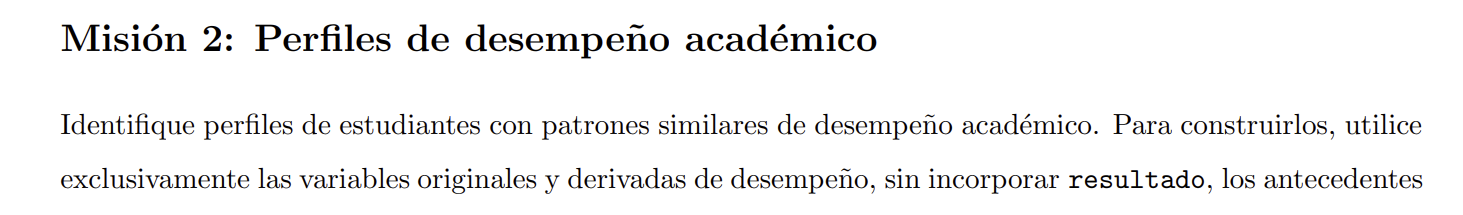

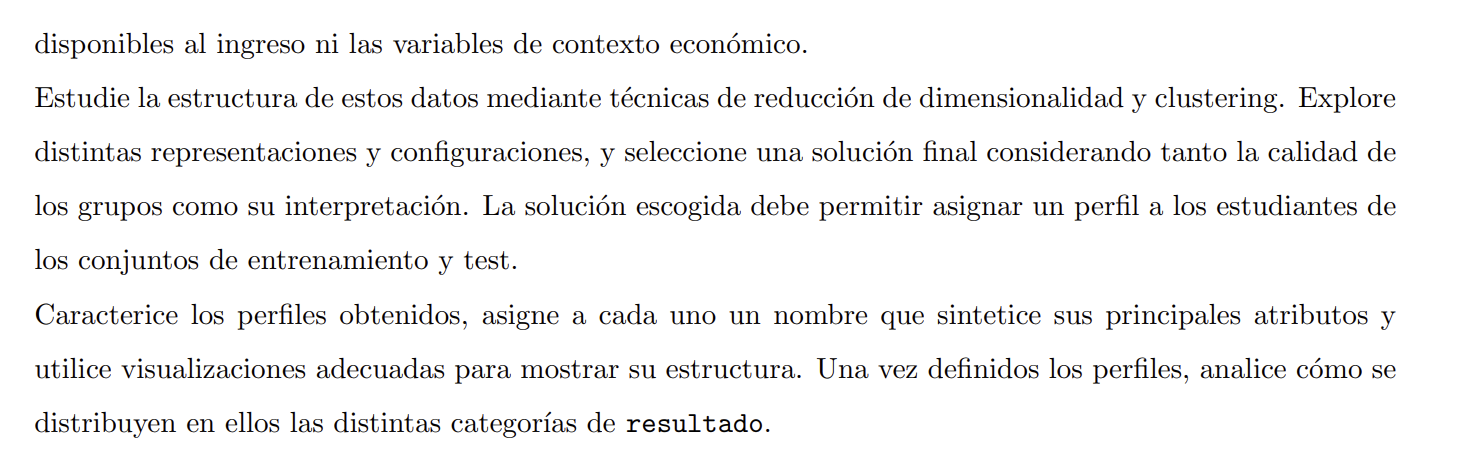

Ahora pasamos a la segmentación de perfiles académicos con técnicas de reducción y clustering.

Comenzamos con la reducción dimensional de las variables originales y derivadas de la misión anterior.

Esto se hace mediante el procedimiento PCA de sklearn.

In [92]:
from sklearn.decomposition import PCA

escalador_desempeno = StandardScaler()
D_entrenamiento = escalador_desempeno.fit_transform(entrenamiento[vars_desempeno])
D_test = escalador_desempeno.transform(test[vars_desempeno])

pca = PCA(n_components=2)
D_entrenamiento_pca = pca.fit_transform(D_entrenamiento)
tabla_pca = pd.DataFrame(D_entrenamiento_pca, columns=['PC1', 'PC2'])

varianza_pc1 = pca.explained_variance_ratio_[0]
varianza_pc2 = pca.explained_variance_ratio_[1]
varianza_total = pca.explained_variance_ratio_.sum()
print(f'Varianza explicada por PC1: {varianza_pc1:.2%}')
print(f'Varianza explicada por PC2: {varianza_pc2:.2%}')
print(f'Varianza explicada por PC1 y PC2: {varianza_total:.2%}')

pesos = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=vars_desempeno)
pesos

Varianza explicada por PC1: 43.41%
Varianza explicada por PC2: 23.51%
Varianza explicada por PC1 y PC2: 66.93%


,PC1,PC2
asignaturas_convalidadas,0.324321,0.075034
asignaturas_inscritas,0.421247,0.045244
evaluaciones_realizadas,0.405465,0.229893
asignaturas_aprobadas,0.461702,-0.142729
promedio_notas,0.386357,-0.156733
asignaturas_sin_evaluacion,0.041923,0.622739
tasa_aprobacion,0.371175,-0.237276
evaluaciones_por_asignatura,0.225667,0.252651
tasa_sin_evaluacion,-0.008372,0.621771


PC1 explica la mayor parte de la variación y resume cuánto inscribe, rinde y aprueba cada estudiante. Es la dirección donde más se diferencian entre sí. PC2 explica menos variación y resume las asignaturas sin evaluar. Explica menos porque la mayoría de los estudiantes evalúa todas sus asignaturas, así que en esa dirección hay menos diferencias.

Por otra parte podemos probar con otro metodo de reducción de dimensionalidad, el t-SNE el cual funciona ajustando a la cercanía de los elementos vecinos y no a la completitud de las variables como PCA.

In [93]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=0
)

D_entrenamiento_tsne = tsne.fit_transform(D_entrenamiento)
tabla_tsne = pd.DataFrame(D_entrenamiento_tsne, columns=['Dim 1', 'Dim 2'])

Con los datos ya representados, pasamos al clustering para formar los perfiles. Probamos K entre 2 y 10 con tres configuraciones: K-means con las 9 variables, K-means sobre PCA y clustering jerárquico. Elegimos la mejor opción con el método del codo y el silhouette.

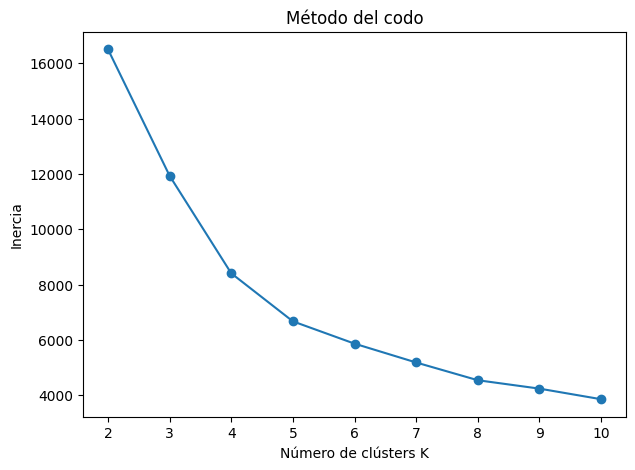

,k,inercia,K-means,K-means PCA,Jerárquico
0,2,16507.172001,0.540049,0.638900,0.516275
1,3,11934.465363,0.576014,0.664230,0.548742
2,4,8409.416203,0.592808,0.692571,0.572403
3,5,6672.179096,0.459540,0.671643,0.425158
4,6,5866.436747,0.445879,0.521642,0.435143
5,7,5185.239298,0.450658,0.553469,0.452356
6,8,4543.930945,0.455619,0.530816,0.458757
7,9,4240.527780,0.360781,0.466800,0.460197
8,10,3857.940587,0.481507,0.456553,0.466602


In [94]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

resultados_clustering = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    etiquetas = kmeans.fit_predict(D_entrenamiento)

    kmeans_pca = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    etiquetas_pca = kmeans_pca.fit_predict(D_entrenamiento_pca)

    jerarquico = AgglomerativeClustering(n_clusters=k)
    etiquetas_jerarquico = jerarquico.fit_predict(D_entrenamiento)

    resultados_clustering.append({
        'k': k,
        'inercia': kmeans.inertia_,
        'K-means': silhouette_score(D_entrenamiento, etiquetas),
        'K-means PCA': silhouette_score(D_entrenamiento_pca, etiquetas_pca),
        'Jerárquico': silhouette_score(D_entrenamiento, etiquetas_jerarquico)
    })

tabla_clustering = pd.DataFrame(resultados_clustering)

plt.figure(figsize=(7, 5))
plt.plot(tabla_clustering['k'], tabla_clustering['inercia'], marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clústers K')
plt.ylabel('Inercia')
plt.show()

tabla_clustering

Nos quedamos con K-means y 4 grupos, usando las 9 variables de desempeño. Con 4 grupos obtiene su mejor silhouette, y además es justo donde se ve el codo del gráfico, así que las dos formas de medir apuntan a lo mismo.

K-means sobre PCA saca un silhouette un poco más alto, pero trabaja con solo dos columnas que resumen parte de la información, cerca del 67%. Preferimos agrupar con todo lo que tenemos sobre el desempeño de cada estudiante.

In [95]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=0)
entrenamiento['perfil'] = kmeans.fit_predict(D_entrenamiento)
test['perfil'] = kmeans.predict(D_test)

resumen_perfiles = entrenamiento.groupby('perfil')[vars_desempeno].mean()
resumen_perfiles

,asignaturas_convalidadas,asignaturas_inscritas,evaluaciones_realizadas,asignaturas_aprobadas,promedio_notas,asignaturas_sin_evaluacion,tasa_aprobacion,evaluaciones_por_asignatura,tasa_sin_evaluacion
perfil,,,,,,,,,
0,0.753086,5.925926,11.395062,2.864198,8.976505,3.049383,0.451412,1.966251,0.537550
1,0.000000,3.917275,3.014599,0.002433,0.024331,0.019465,0.000487,0.566452,0.003531
2,0.219610,6.173587,8.456228,5.188094,12.699183,0.038519,0.836058,1.390114,0.006635
3,9.036810,13.361963,16.515337,11.797546,12.608469,0.196319,0.878583,1.248084,0.012788


Con esta segmentación podriamos empezar a definir ciertos clusters, por ejemplo vemos que el perfil 0 deja en promedio 3 ramos sin evaluar. Llamemoslo Evaluaciones pendientes.

El perfil 1 no convalida, inscribe ramos pero los aprueba poco, para un poco de amabilidad le ponemos Sin aprobaciones.

El perfil 2 se comporta mas como un estudiante promedio, que inscribe y aprueba sus ramos de forma regular, Regular aprobador.

Y el perfil 3 convalida bastante, Alta carga convalidada.

Ya con los clusters definidos, aplicamos estos nombres a entrenamiento y a test, y también a las tablas de PCA y t-SNE para poder graficar los perfiles.

In [96]:
nombres_perfiles = {
    0: 'Evaluaciones pendientes',
    1: 'Sin aprobaciones',
    2: 'Regular aprobador',
    3: 'Alta carga convalidada'
}

entrenamiento['perfil'] = entrenamiento['perfil'].map(nombres_perfiles)
test['perfil'] = test['perfil'].map(nombres_perfiles)

tabla_pca['perfil'] = entrenamiento['perfil'].values
tabla_tsne['perfil'] = entrenamiento['perfil'].values

print(entrenamiento['perfil'].value_counts())

perfil
Regular aprobador          1999
Sin aprobaciones            411
Alta carga convalidada      163
Evaluaciones pendientes      81
Name: count, dtype: int64


Los perfiles quedan muy desiguales en tamaño. Regular aprobador reúne a casi 2.000 estudiantes, tres de cada cuatro, y representa el comportamiento más común. En el otro extremo, Evaluaciones pendientes tiene solo 81. Esto hay que tenerlo presente más adelante, porque en los perfiles pequeños los resultados pueden ser menos estables.

Finalmente visualizamos los clusters en base a los distintos métodos de dimensionalidad, y veremos que si bien en la misma cantidad de grupos, el mecanismo tiende a unificar mas al perfil Regular aprobador por el propio comportamiento de vecindad de t-SNE.

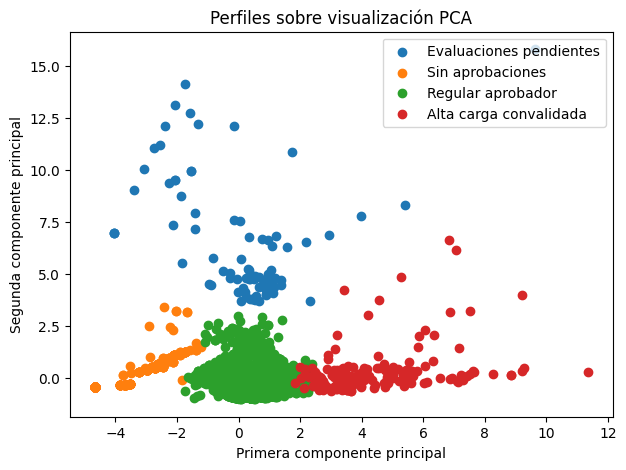

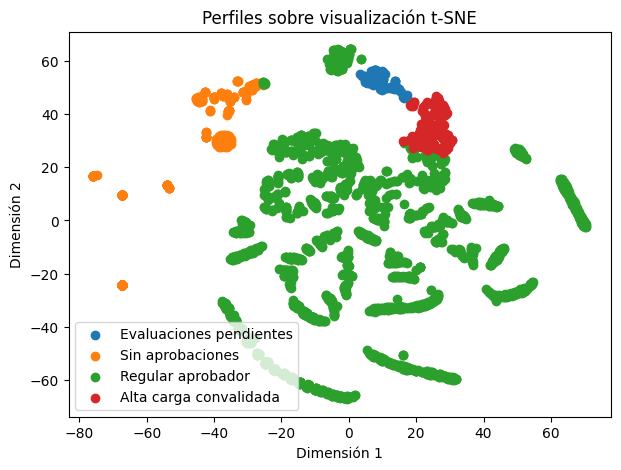

In [97]:
plt.figure(figsize=(7, 5))
for nombre in nombres_perfiles.values():
    grupo = tabla_pca[tabla_pca['perfil'] == nombre]
    plt.scatter(grupo['PC1'], grupo['PC2'], label=nombre)
plt.title('Perfiles sobre visualización PCA')
plt.xlabel('Primera componente principal')
plt.ylabel('Segunda componente principal')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
for nombre in nombres_perfiles.values():
    grupo = tabla_tsne[tabla_tsne['perfil'] == nombre]
    plt.scatter(grupo['Dim 1'], grupo['Dim 2'], label=nombre)
plt.title('Perfiles sobre visualización t-SNE')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.legend()
plt.show()

Los perfiles se formaron sin usar el resultado de la trayectoria. Ahora sí lo miramos, para ver si estos grupos de desempeño se relacionan con que un estudiante abandone, siga matriculado o se gradúe.

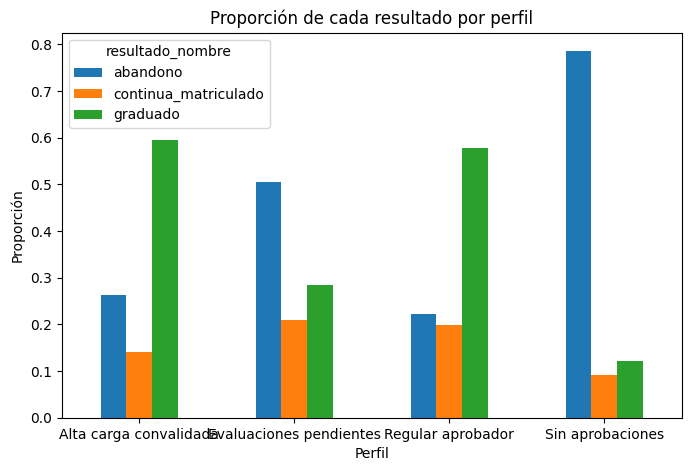

resultado_nombre,abandono,continua_matriculado,graduado
perfil,,,
Alta carga convalidada,0.263804,0.141104,0.595092
Evaluaciones pendientes,0.506173,0.209877,0.283951
Regular aprobador,0.223112,0.199100,0.577789
Sin aprobaciones,0.785888,0.092457,0.121655


In [98]:
entrenamiento['resultado_nombre'] = codificador.inverse_transform(entrenamiento[objetivo])

proporciones = entrenamiento.groupby('perfil')['resultado_nombre'].value_counts(normalize=True)
distribucion = proporciones.unstack()

distribucion.plot(kind='bar', figsize=(8, 5))
plt.title('Proporción de cada resultado por perfil')
plt.xlabel('Perfil')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.show()

distribucion

Regular aprobador: carga típica de 6 asignaturas, aprueba el 84% y tiene promedio 12,7. Su resultado más frecuente es graduado con 58%.

Alta carga convalidada: inscribe 13 asignaturas, convalida 9 y aprueba el 88%. Su resultado más frecuente es graduado con 60%.

Sin aprobaciones: inscribe 4 asignaturas y no aprueba ninguna. Su resultado más frecuente es abandono con 79%.

Evaluaciones pendientes: deja 3 asignaturas sin evaluar y aprueba el 45%. Su resultado más frecuente es abandono con 51%.

## Misión 3: Predicción de la trayectoria académica

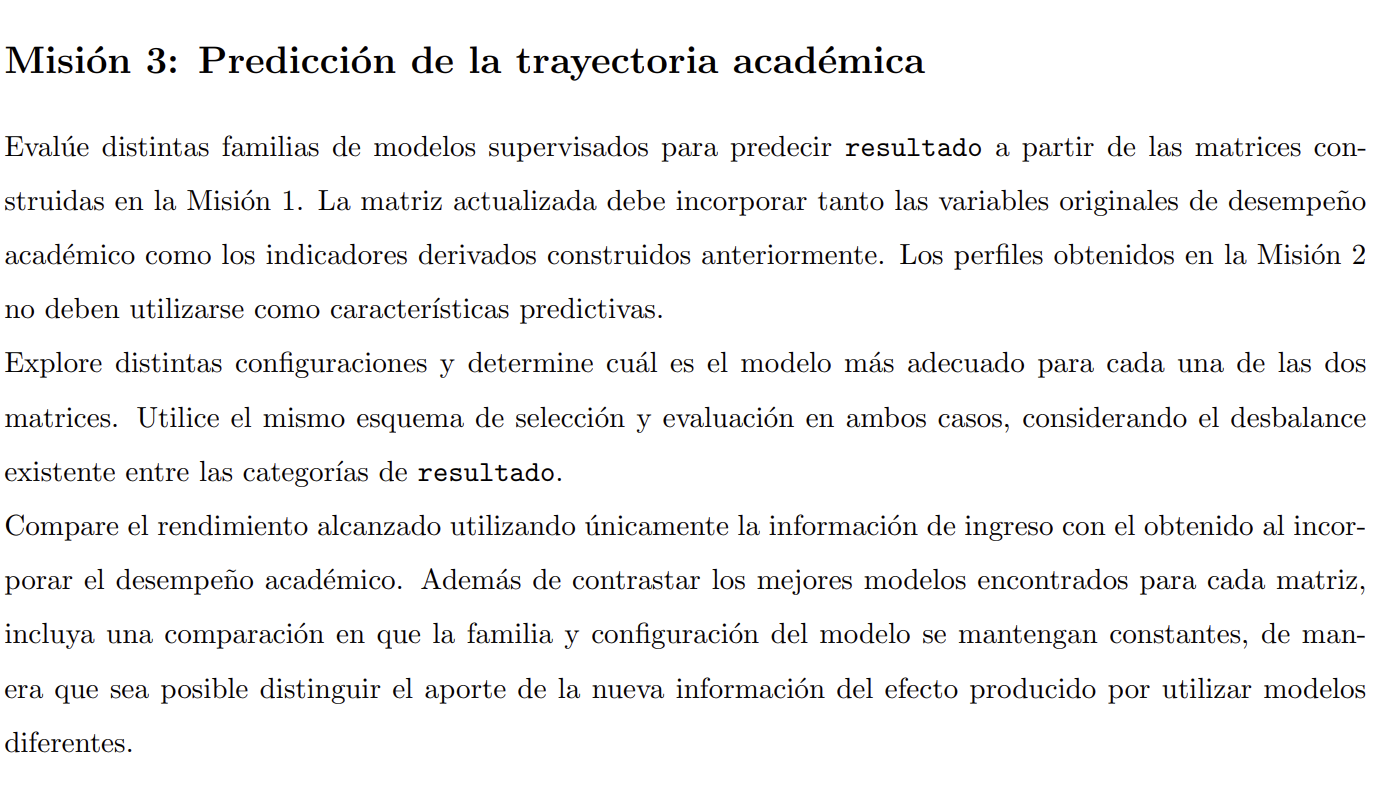

Antes de comenzar, debemos determinar el desbalance de las clases de los estados de los estudiantes del dataset, para esto podemos hacer un analisis sencillo

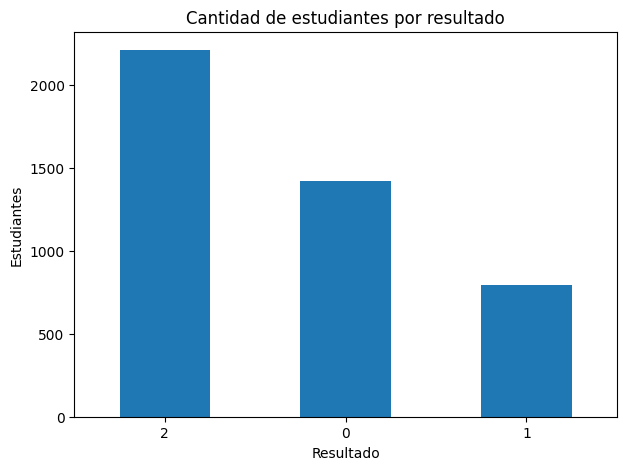

,count
resultado,
2,0.499322
0,0.321203
1,0.179476


In [99]:
conteo_resultado = datos['resultado'].value_counts()

conteo_resultado.plot(kind='bar', figsize=(7, 5))
plt.title('Cantidad de estudiantes por resultado')
plt.xlabel('Resultado')
plt.ylabel('Estudiantes')
plt.xticks(rotation=0)
plt.show()

conteo_resultado / len(datos)

En esta misión intentamos predecir el resultado de cada estudiante: si abandona, sigue matriculado o se gradúa. Lo hacemos dos veces, una con la matriz de ingreso y otra con la matriz actualizada, para ver cuánto ayuda conocer el desempeño académico.

Para que la comparación sea justa, las dos matrices siguen exactamente el mismo proceso. Los modelos aprenden con el conjunto de entrenamiento, luego los comparamos en validación para elegir el mejor, y al final medimos ese modelo una sola vez en test.

Para medir qué tan bien predice cada modelo usamos balanced accuracy. La razón es que las clases están desbalanceadas: la mitad de los estudiantes se gradúa. Un modelo que dijera "graduado" para todos acertaría el 50% de las veces sin haber aprendido nada. Balanced accuracy calcula el acierto en cada clase por separado y luego los promedia, así que ese modelo tramposo sacaría solo 0,33.

Probamos tres familias de modelos, cada una con varias configuraciones. En KNN cambiamos la cantidad de vecinos que votan. En el árbol de decisión cambiamos su profundidad máxima, es decir, cuántas preguntas puede hacer antes de decidir. En SVM cambiamos C, que controla qué tan estricta es la frontera entre clases.

In [100]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

modelos = {}

for k in [1, 3, 5, 7, 9, 11]:
    modelos[f'KNN (K={k})'] = KNeighborsClassifier(n_neighbors=k)

for profundidad in [3, 5, 7, 10]:
    modelos[f'Árbol (profundidad máxima={profundidad})'] = DecisionTreeClassifier(
        max_depth=profundidad, class_weight='balanced', random_state=42
    )

for c in [0.1, 1, 10]:
    modelos[f'SVM (C={c})'] = SVC(C=c, class_weight='balanced')

Con los modelos definidos, los entrenamos y comparamos. El ciclo recorre las dos matrices y, para cada una, prueba los 13 modelos. En total son 26 entrenamientos.

En cada vuelta hacemos lo mismo. Primero creamos una copia nueva del modelo con clone, para que parta desde cero y no arrastre nada de la matriz anterior. Luego lo entrenamos con los datos de entrenamiento, predecimos el resultado de los estudiantes de validación y calculamos la balanced accuracy de esas predicciones.

Al final armamos una tabla con una fila por modelo y una columna por matriz. Así podemos comparar de un vistazo cómo le fue a cada modelo con la información de ingreso y con la información actualizada.

In [101]:
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score

resultados_validacion = []

for matriz, (X_entrenamiento, X_validacion, X_test) in matrices.items():
    for nombre_modelo, modelo in modelos.items():
        modelo_nuevo = clone(modelo)
        modelo_nuevo.fit(X_entrenamiento, y_entrenamiento)
        predicciones = modelo_nuevo.predict(X_validacion)
        puntaje = balanced_accuracy_score(y_validacion, predicciones)
        resultados_validacion.append({
            'matriz': matriz,
            'modelo': nombre_modelo,
            'balanced_accuracy': puntaje
        })

tabla_validacion = pd.DataFrame(resultados_validacion)
tabla_validacion = tabla_validacion.pivot(index='modelo', columns='matriz', values='balanced_accuracy')
tabla_validacion

matriz,actualizada,ingreso
modelo,,
KNN (K=1),0.573335,0.485571
KNN (K=11),0.574732,0.502228
KNN (K=3),0.589590,0.493948
KNN (K=5),0.594872,0.512478
KNN (K=7),0.581195,0.505175
KNN (K=9),0.573478,0.506175
SVM (C=0.1),0.653099,0.548992
SVM (C=1),0.684360,0.530379
SVM (C=10),0.644786,0.525002


Con solo la información de ingreso, ningún modelo supera 0,55. Es mejor que adivinar al azar, que daría cerca de 0,33, pero todavía cuesta predecir el resultado. Al agregar el desempeño académico, todos los modelos mejoran y el mejor llega a 0,68. SVM es la familia que mejor funciona en ambos casos, y KNN la que peor.

In [102]:
mejor_ingreso = tabla_validacion['ingreso'].idxmax()
mejor_actualizada = tabla_validacion['actualizada'].idxmax()

promedio_validacion = tabla_validacion.mean(axis=1)
modelo_fijo = promedio_validacion.idxmax()

print(f'Mejor modelo ingreso: {mejor_ingreso}')
print(f'Mejor modelo actualizada: {mejor_actualizada}')
print(f'Configuración fija: {modelo_fijo}')

Mejor modelo ingreso: SVM (C=0.1)
Mejor modelo actualizada: SVM (C=1)
Configuración fija: SVM (C=1)


Con la matriz de ingreso gana SVM con C = 0,1 y con la actualizada gana SVM con C = 1. Debemos determinar finalmente con que C nos quedaremos.

In [103]:
evaluaciones = [
    ('Mejor modelo', 'ingreso', mejor_ingreso),
    ('Mejor modelo', 'actualizada', mejor_actualizada),
    ('Configuración fija', 'ingreso', modelo_fijo),
    ('Configuración fija', 'actualizada', modelo_fijo)
]

modelos_finales = {}
resultados_test = []

for comparacion, matriz, nombre_modelo in evaluaciones:
    X_entrenamiento, X_validacion, X_test = matrices[matriz]

    modelo_final = clone(modelos[nombre_modelo])
    modelo_final.fit(X_entrenamiento, y_entrenamiento)
    predicciones = modelo_final.predict(X_test)
    puntaje = balanced_accuracy_score(y_test, predicciones)

    if comparacion == 'Mejor modelo':
        modelos_finales[matriz] = modelo_final

    resultados_test.append({
        'comparacion': comparacion,
        'matriz': matriz,
        'modelo': nombre_modelo,
        'balanced_accuracy': puntaje
    })

tabla_test = pd.DataFrame(resultados_test)
tabla_test

,comparacion,matriz,modelo,balanced_accuracy
0,Mejor modelo,ingreso,SVM (C=0.1),0.511092
1,Mejor modelo,actualizada,SVM (C=1),0.679914
2,Configuración fija,ingreso,SVM (C=1),0.535907
3,Configuración fija,actualizada,SVM (C=1),0.679914


Con información de ingreso, el mejor modelo alcanza 0,51 en test. Al agregar el desempeño académico sube a 0,68. Para saber cuánto de esa mejora se debe a la información, miramos la configuración fija: con el mismo modelo, la balanced accuracy pasa de 0,54 a 0,68. Como el modelo no cambia, esa mejora de 0,14 se debe solo a conocer el desempeño del estudiante. En resumen, la información de desempeño explica casi toda la mejora, y cambiar de modelo influye muy poco.

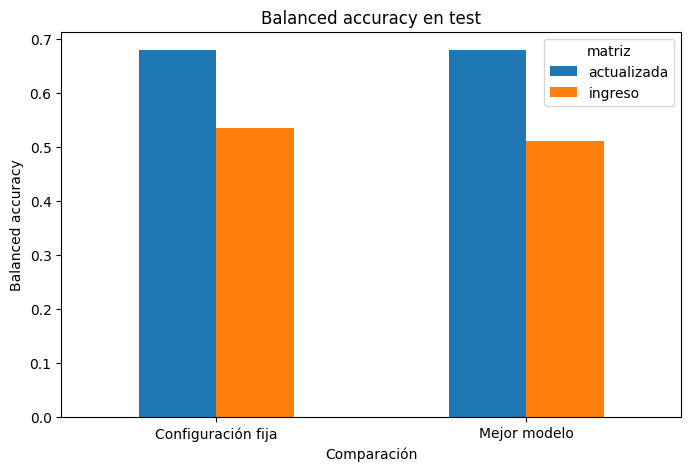

In [104]:
grafico_test = tabla_test.pivot(index='comparacion', columns='matriz', values='balanced_accuracy')

grafico_test.plot(kind='bar', figsize=(8, 5))
plt.title('Balanced accuracy en test')
plt.xlabel('Comparación')
plt.ylabel('Balanced accuracy')
plt.xticks(rotation=0)
plt.show()

Con la matriz de ingreso el mejor modelo es SVM con C = 0.1 y con la matriz actualizada es SVM con C = 1. En test la balanced accuracy sube de 0,51 a 0,68.

Con la configuración fija, SVM con C = 1, la balanced accuracy sube de 0,54 a 0,68. Al mantener el mismo modelo, esta mejora de 0,14 corresponde a la información de desempeño. El cambio de configuración aporta cerca de 0,02.

## Misión 4: Predicción según perfiles de desempeño

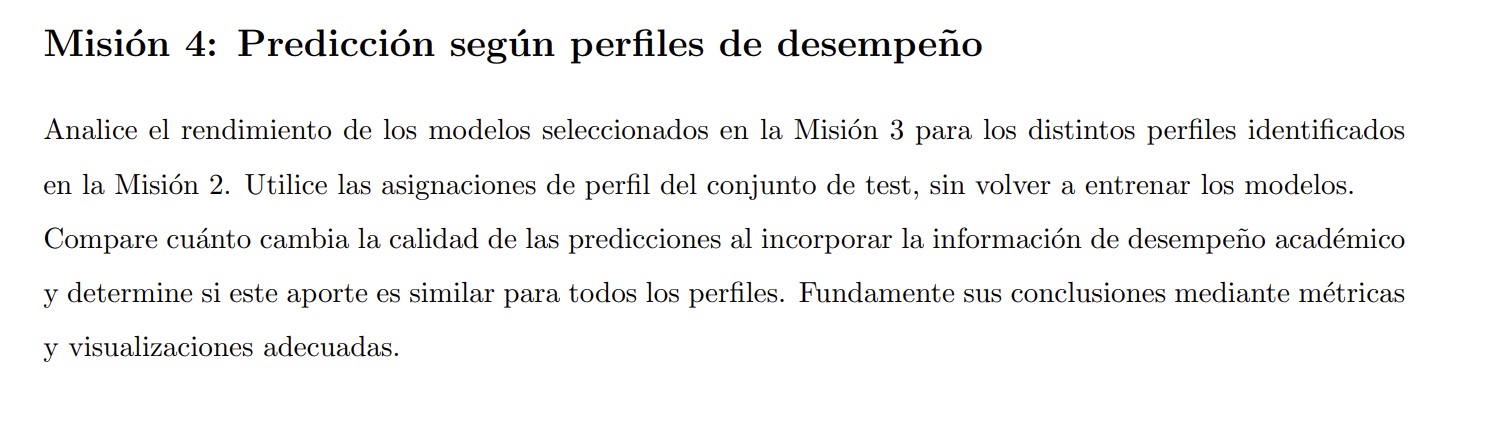

En esta misión vemos si los modelos predicen igual de bien para todos los perfiles. Usamos los dos modelos que guardamos en la Misión 3, el mejor con información de ingreso y el mejor con información actualizada, sin volver a entrenarlos.

Para cada perfil tomamos solo a sus estudiantes del conjunto de test y calculamos la balanced accuracy de ambos modelos. La columna aporte es la diferencia entre los dos, y muestra cuánto mejora la predicción en ese perfil al conocer el desempeño académico.

In [105]:
resultados_perfiles = []

for nombre in nombres_perfiles.values():
    mascara = (test['perfil'] == nombre).values
    fila = {'perfil': nombre, 'n_test': mascara.sum()}

    for matriz, (X_entrenamiento, X_validacion, X_test) in matrices.items():
        predicciones = modelos_finales[matriz].predict(X_test[mascara])
        fila[matriz] = balanced_accuracy_score(y_test[mascara], predicciones)

    resultados_perfiles.append(fila)

tabla_perfiles = pd.DataFrame(resultados_perfiles)
tabla_perfiles = tabla_perfiles.set_index('perfil')
tabla_perfiles['aporte'] = tabla_perfiles['actualizada'] - tabla_perfiles['ingreso']
tabla_perfiles

,n_test,ingreso,actualizada,aporte
perfil,,,,
Evaluaciones pendientes,25,0.294872,0.304487,0.009615
Sin aprobaciones,117,0.384503,0.441520,0.057018
Regular aprobador,683,0.529649,0.647366,0.117717
Alta carga convalidada,60,0.416279,0.771189,0.354910


El aporte del desempeño cambia mucho según el perfil.

Donde más ayuda es en Alta carga convalidada, que pasa de 0,42 a 0,77. Con los datos de ingreso costaba predecir a estos estudiantes, pero su desempeño dice mucho de ellos. En Regular aprobador, el perfil más grande, la mejora es más moderada, de 0,53 a 0,65.

En los perfiles de bajo desempeño la historia es otra. Sin aprobaciones apenas mejora, de 0,38 a 0,44, porque casi todos abandonan y al modelo le cuesta reconocer a los pocos que no lo hacen. Evaluaciones pendientes prácticamente no cambia, de 0,29 a 0,30, y queda incluso bajo lo que daría adivinar al azar. Con solo 25 estudiantes en test, además, es un resultado poco estable.

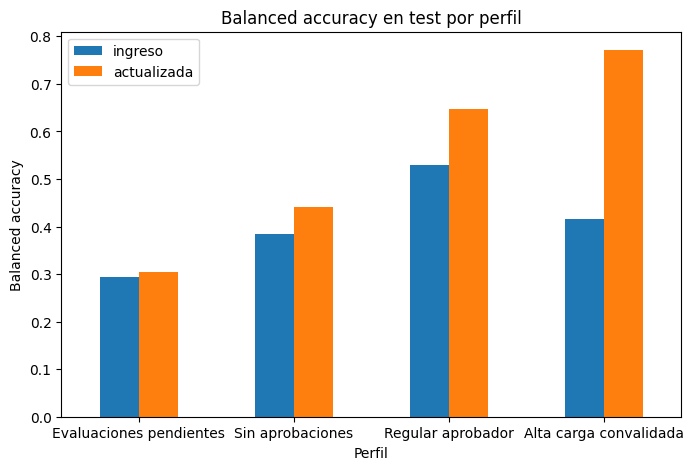

In [106]:
tabla_perfiles[['ingreso', 'actualizada']].plot(kind='bar', figsize=(8, 5))
plt.title('Balanced accuracy en test por perfil')
plt.xlabel('Perfil')
plt.ylabel('Balanced accuracy')
plt.xticks(rotation=0)
plt.show()

En el gráfico se nota a simple vista: la barra de la matriz actualizada crece mucho en los perfiles que aprueban asignaturas y casi nada en los otros dos.

Conocer el desempeño del primer periodo sirve bastante para predecir qué pasará con un estudiante, pero no por igual para todos. Funciona bien con quienes van aprobando. Con quienes tienen dificultades desde el inicio, el resultado sigue siendo difícil de anticipar, y probablemente dependa de cosas que estos datos no alcanzan a mostrar.